# Penyeimbangan Data Ecoli SMOTE

Jumlah baris: 337
   id_protein  feature1  feature2  feature3  feature4  feature5  feature6  \
0   AAS_ECOLI      0.44      0.52      0.48       0.5      0.43      0.47   
1   AAT_ECOLI      0.49      0.29      0.48       0.5      0.56      0.24   
2  ACEA_ECOLI      0.07      0.40      0.48       0.5      0.54      0.35   
3  ACEK_ECOLI      0.56      0.40      0.48       0.5      0.49      0.37   
4  ACKA_ECOLI      0.59      0.49      0.48       0.5      0.52      0.45   

   feature7 class_label  
0      0.54          im  
1      0.35          cp  
2      0.44          cp  
3      0.46          cp  
4      0.36          cp  


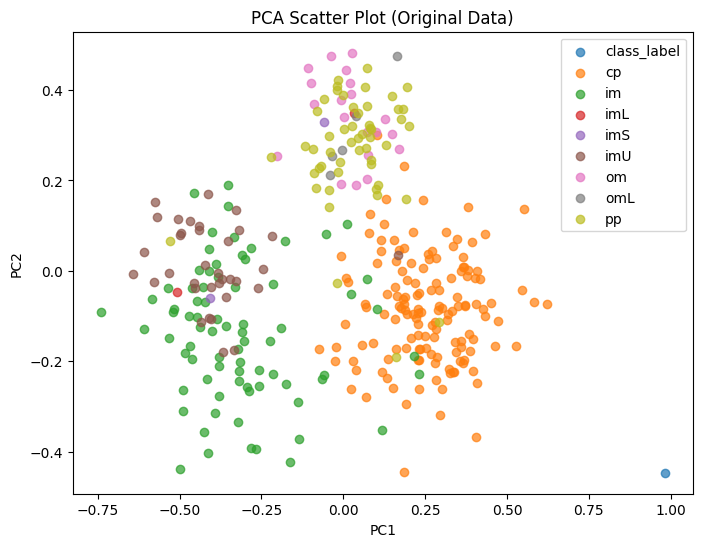

Distribusi kelas sebelum balancing: Counter({'cp': 143, 'im': 77, 'pp': 52, 'imU': 35, 'om': 20, 'omL': 5, 'imS': 2, 'imL': 2, 'class_label': 1})


Distribusi kelas setelah balancing: Counter({'class_label': 143, 'cp': 143, 'im': 143, 'imL': 143, 'imS': 143, 'imU': 143, 'om': 143, 'omL': 143, 'pp': 143})


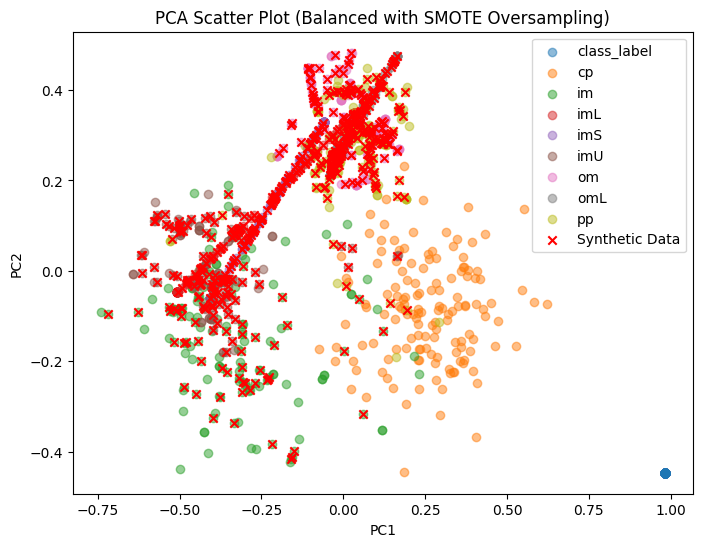

✅ Hasil balancing SMOTE berhasil disimpan ke 'ecoli_balanced_smote.csv'


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sqlalchemy import create_engine
from collections import Counter

# === 1. Koneksi ke MySQL XAMPP ===
engine = create_engine("mysql+pymysql://root:@localhost:3306/ecoli")

# ambil data dari tabel
df = pd.read_sql("SELECT * FROM ecoli;", engine)

print("Jumlah baris:", len(df))
print(df.head())

# === 3. Pisahkan fitur & label ===
X = df[[f"feature{i}" for i in range(1, 8)]].values
y = df["class_label"].values

# === 4. PCA untuk data asli ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
for label in np.unique(y):
    idx = (y == label)
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=label, alpha=0.7)
plt.title("PCA Scatter Plot (Original Data)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(); plt.show()

# === 5. Custom SMOTE Oversampling ===
class_counts = Counter(y)
print("Distribusi kelas sebelum balancing:", class_counts)

max_class_size = max(class_counts.values())
X_res, y_res = [], []

k_neighbors = 5  # jumlah tetangga untuk interpolasi

for cls in np.unique(y):
    X_cls = X[y == cls]
    n_samples = len(X_cls)
    n_to_add = max_class_size - n_samples

    X_res.append(X_cls)
    y_res.extend([cls] * n_samples)

    if n_to_add > 0:
        # Cari k tetangga terdekat
        nn = NearestNeighbors(n_neighbors=min(k_neighbors, len(X_cls)))
        nn.fit(X_cls)

        synthetic_samples = []
        for _ in range(n_to_add):
            i = np.random.randint(0, len(X_cls))
            x_i = X_cls[i].reshape(1, -1)

            neighbors = nn.kneighbors(x_i, return_distance=False)
            neighbor_idx = np.random.choice(neighbors[0])
            x_neighbor = X_cls[neighbor_idx]

            # Interpolasi linear (SMOTE)
            lam = np.random.rand()
            x_new = x_i + lam * (x_neighbor - x_i)
            synthetic_samples.append(x_new.flatten())

        X_res.append(np.array(synthetic_samples))
        y_res.extend([cls] * n_to_add)

X_res = np.vstack(X_res)
y_res = np.array(y_res)

print("Distribusi kelas setelah balancing:", Counter(y_res))

# === 6. Tandai data sintetis ===
X_rounded = np.round(X, 5)
X_res_rounded = np.round(X_res, 5)
synthetic_mask = [tuple(x) not in set(map(tuple, X_rounded)) for x in X_res_rounded]

# === 7. PCA untuk hasil balancing ===
X_res_pca = pca.transform(X_res)

plt.figure(figsize=(8,6))
for label in np.unique(y_res):
    idx = (y_res == label)
    plt.scatter(X_res_pca[idx,0], X_res_pca[idx,1], label=label, alpha=0.5)

plt.scatter(X_res_pca[synthetic_mask,0], X_res_pca[synthetic_mask,1],
            c="red", marker="x", label="Synthetic Data")

plt.title("PCA Scatter Plot (Balanced with SMOTE Oversampling)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(); plt.show()

# === 8. Simpan hasil balancing ke CSV ===
df_balanced = pd.DataFrame(X_res, columns=[f"feature{i}" for i in range(1, 8)])
df_balanced["class_label"] = y_res

# tambahkan kolom id_protein (auto-generate)
df_balanced.insert(0, "id_protein", [f"P{str(i+1).zfill(4)}" for i in range(len(df_balanced))])

df_balanced.to_csv("ecoli_balanced_smote.csv", index=False)
print("✅ Hasil balancing SMOTE berhasil disimpan ke 'ecoli_balanced_smote.csv'")
